In [1]:
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
mrl_isoform = np.load( path + 'mrl_isoform_resolved.npz')

In [3]:
investigate_dataset(mrl_isoform)

['X', 'y', 'genes']

Array shapes:
X shape: (11693, 12288, 6)
y shape: (11693,)
genes shape: (11693,)

First few y values: [5.40141546 3.33709259 5.41937329 5.74227841 5.32184319]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [1. 0. 0. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(mrl_isoform['X'], mrl_isoform['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (11693, 2048)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 72.12%


In [6]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, mrl_isoform['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715553,...,-0.276002,0.476510,0.048652,0.615735,-0.304542,0.817905,-0.186548,-0.250117,-0.162477,0.061585
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,0.625080,-0.043918,0.110276,-0.887310,0.245636,-0.010913,-0.086300,1.471260,0.575406,-0.383124
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.034905,0.926175,0.611508,-1.506367,0.640327,0.425503,0.289503,0.606739,0.078263,-0.612264
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,0.036734,0.726153,-0.134809,0.378255,0.522915,0.041985,-0.439623,-0.111074,-0.314714,0.589748
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-0.464299,-0.683750,0.929115,-0.483678,-0.060633,-0.839158,0.050779,0.681815,0.862542,0.825013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,0.296039,-0.027637,0.180094,0.293949,-0.041880,-0.019966,-0.109211,-0.249579,0.028970,-0.000726
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579754,...,-0.839925,-0.375263,-0.471491,0.268046,-0.147472,0.763085,-0.297193,-0.326933,-0.332667,0.878555
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,-0.612183,0.069096,-0.388617,-0.080010,0.595819,-0.164186,0.104135,0.310028,-0.607647,-0.460592


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715553,...,-0.276002,0.476510,0.048652,0.615735,-0.304542,0.817905,-0.186548,-0.250117,-0.162477,0.061585
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,0.625080,-0.043918,0.110276,-0.887310,0.245636,-0.010913,-0.086300,1.471260,0.575406,-0.383124
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.034905,0.926175,0.611508,-1.506367,0.640327,0.425503,0.289503,0.606739,0.078263,-0.612264
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,0.036734,0.726153,-0.134809,0.378255,0.522915,0.041985,-0.439623,-0.111074,-0.314714,0.589748
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-0.464299,-0.683750,0.929115,-0.483678,-0.060633,-0.839158,0.050779,0.681815,0.862542,0.825013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,0.296039,-0.027637,0.180094,0.293949,-0.041880,-0.019966,-0.109211,-0.249579,0.028970,-0.000726
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579754,...,-0.839925,-0.375263,-0.471491,0.268046,-0.147472,0.763085,-0.297193,-0.326933,-0.332667,0.878555
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,-0.612183,0.069096,-0.388617,-0.080010,0.595819,-0.164186,0.104135,0.310028,-0.607647,-0.460592


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715553,...,-0.304542,0.817905,-0.186548,-0.250117,-0.162477,0.061585,False,False,False,False
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,0.245636,-0.010913,-0.086300,1.471260,0.575406,-0.383124,False,False,False,False
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.640327,0.425503,0.289503,0.606739,0.078263,-0.612264,False,False,False,False
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,0.522915,0.041985,-0.439623,-0.111074,-0.314714,0.589748,False,False,False,False
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-0.060633,-0.839158,0.050779,0.681815,0.862542,0.825013,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SCO2,-11.021691,-8.526528,-5.202515,-2.475116,-1.106725,-2.811286,7.074593,0.870503,3.028499,-0.628025,...,0.015736,-0.038559,0.296274,-0.278904,0.136311,0.557805,False,False,False,False
TBCE,-3.199916,-0.195192,13.523295,6.196819,-5.897826,-0.775914,0.624610,1.177227,2.232309,3.613913,...,0.468519,0.433812,-0.465168,-0.275634,0.288527,-0.080932,False,False,False,False
ABCF2,16.090095,17.135822,-9.145933,4.259971,6.373613,1.688988,-0.188709,2.161776,3.379265,-0.509944,...,0.019237,-0.567709,0.249353,0.504691,-1.023606,0.117272,False,True,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    5610
True      331
Name: count, dtype: int64

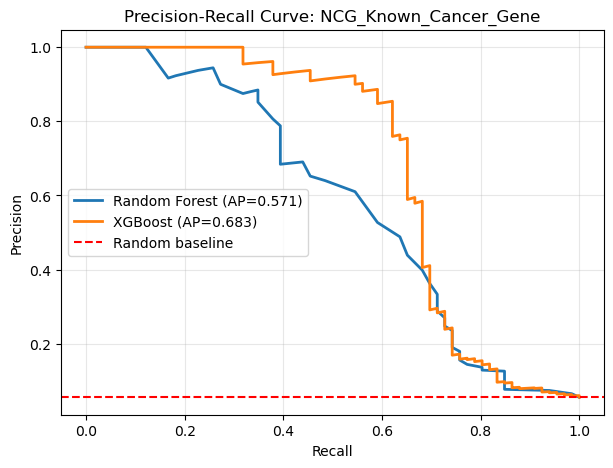

Random Forest - auPRC: 0.571
XGBoost - auPRC: 0.683



In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    5450
True      491
Name: count, dtype: int64

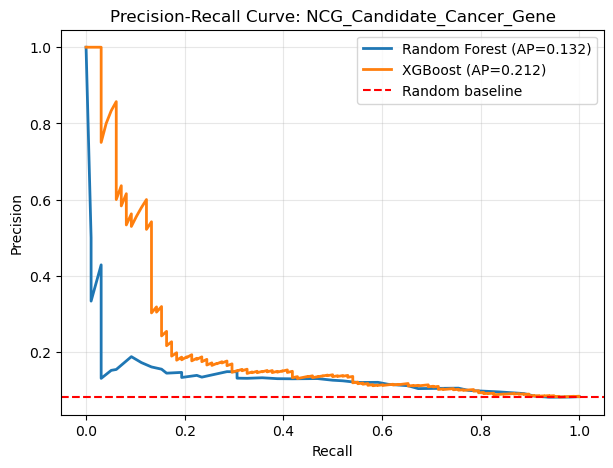

Random Forest - auPRC: 0.132
XGBoost - auPRC: 0.212



In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    5675
True      266
Name: count, dtype: int64

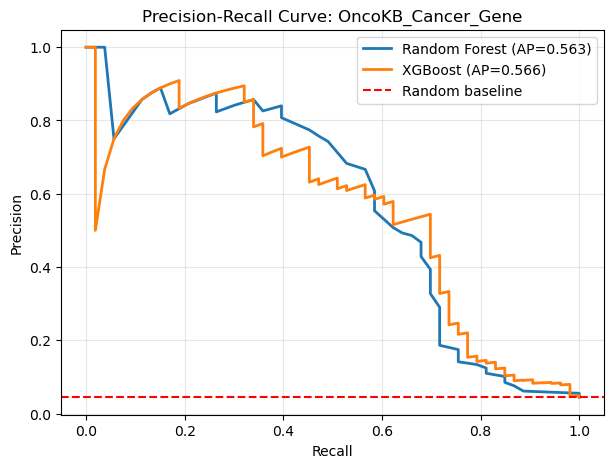

Random Forest - auPRC: 0.563
XGBoost - auPRC: 0.566



In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    5788
True      153
Name: count, dtype: int64

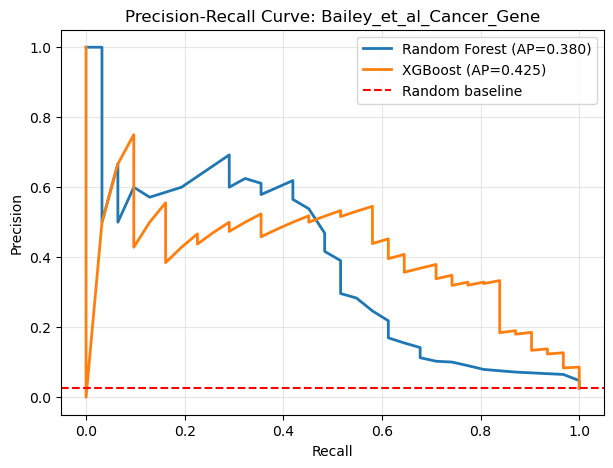

Random Forest - auPRC: 0.380
XGBoost - auPRC: 0.425



In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')